In [3]:
# ============================================================
# Employee Attrition Prediction - Exploratory Data Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
# Path to the dataset (update if needed)
data_path = r"C:\Users\Pratyush\OneDrive\Desktop\ML-DE Final Project\WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Check if file exists
if not os.path.exists(data_path):
    print(f"File not found at: {data_path}")
    print("Please download the dataset and place it in the data/raw/ folder.")
else:
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully!")
    print("Shape:", df.shape)
    display(df.head())

Dataset loaded successfully!
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [6]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names:\n{df.columns.tolist()}")

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

DATASET OVERVIEW

Shape: 1470 rows × 35 columns

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

DATA TYPES
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64


Attrition Value Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


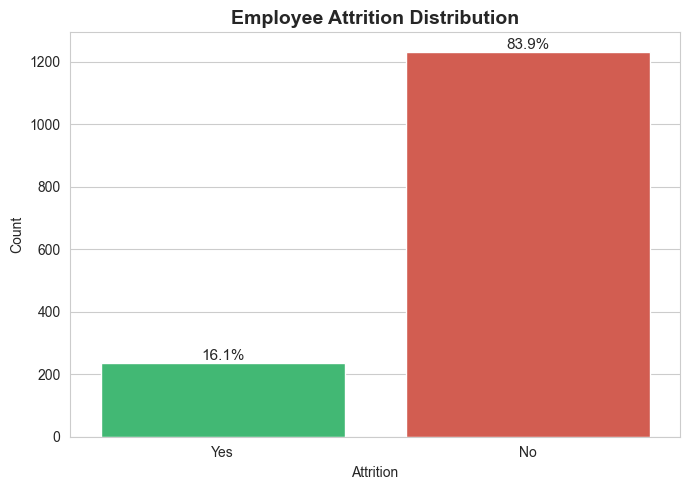

In [7]:
print("Attrition Value Counts:")
print(df["Attrition"].value_counts())
print("\nAttrition Percentage:")
print(df["Attrition"].value_counts(normalize=True).round(4) * 100)

# Plot
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="Attrition", palette=["#2ecc71", "#e74c3c"])
plt.title("Employee Attrition Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Attrition")
plt.ylabel("Count")

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(percentage, (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

In [8]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numerical Columns:", numerical_cols)
print("\n")
df[numerical_cols].describe().T

Numerical Columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']




,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [9]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical Columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n----- {col} -----")
    print(df[col].value_counts())

Categorical Columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

----- Attrition -----
Attrition
No     1233
Yes     237
Name: count, dtype: int64

----- BusinessTravel -----
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

----- Department -----
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

----- EducationField -----
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

----- Gender -----
Gender
Male      882
Female    588
Name: count, dtype: int64

----- JobRole -----
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Represen

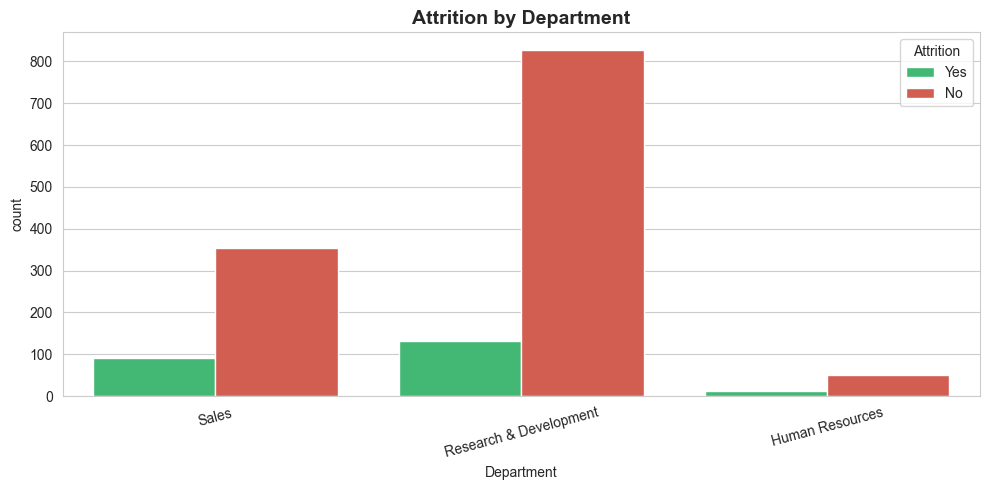


Attrition Rate by Department (%):
Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Department", hue="Attrition", palette=["#2ecc71", "#e74c3c"])
plt.title("Attrition by Department", fontsize=14, fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Percentage view
dept_attrition = pd.crosstab(df["Department"], df["Attrition"], normalize="index") * 100
print("\nAttrition Rate by Department (%):")
print(dept_attrition.round(2))

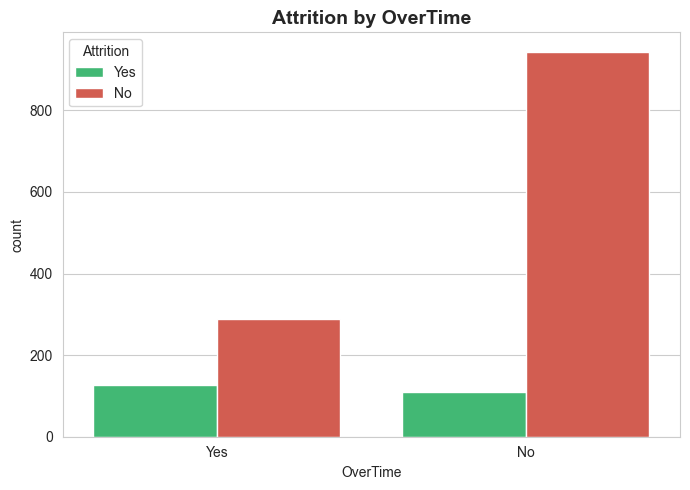


Attrition Rate by OverTime (%):
Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53


In [11]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="OverTime", hue="Attrition", palette=["#2ecc71", "#e74c3c"])
plt.title("Attrition by OverTime", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

ot_attrition = pd.crosstab(df["OverTime"], df["Attrition"], normalize="index") * 100
print("\nAttrition Rate by OverTime (%):")
print(ot_attrition.round(2))

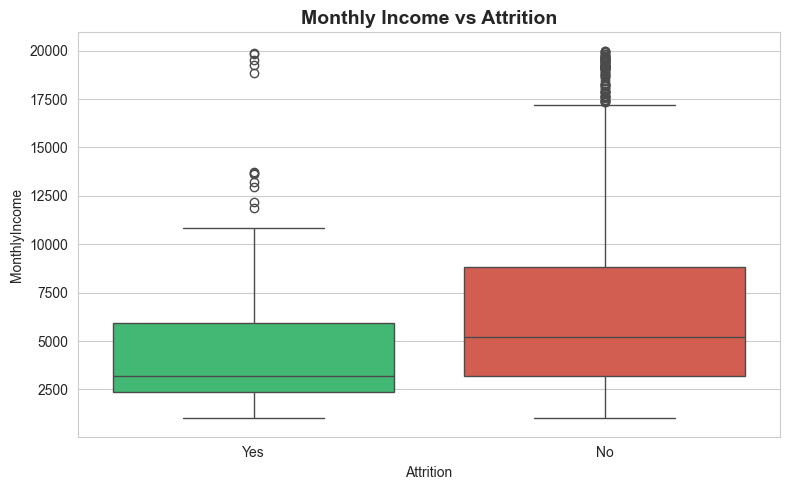


Average Monthly Income by Attrition:
Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64


In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", palette=["#2ecc71", "#e74c3c"])
plt.title("Monthly Income vs Attrition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nAverage Monthly Income by Attrition:")
print(df.groupby("Attrition")["MonthlyIncome"].mean().round(2))

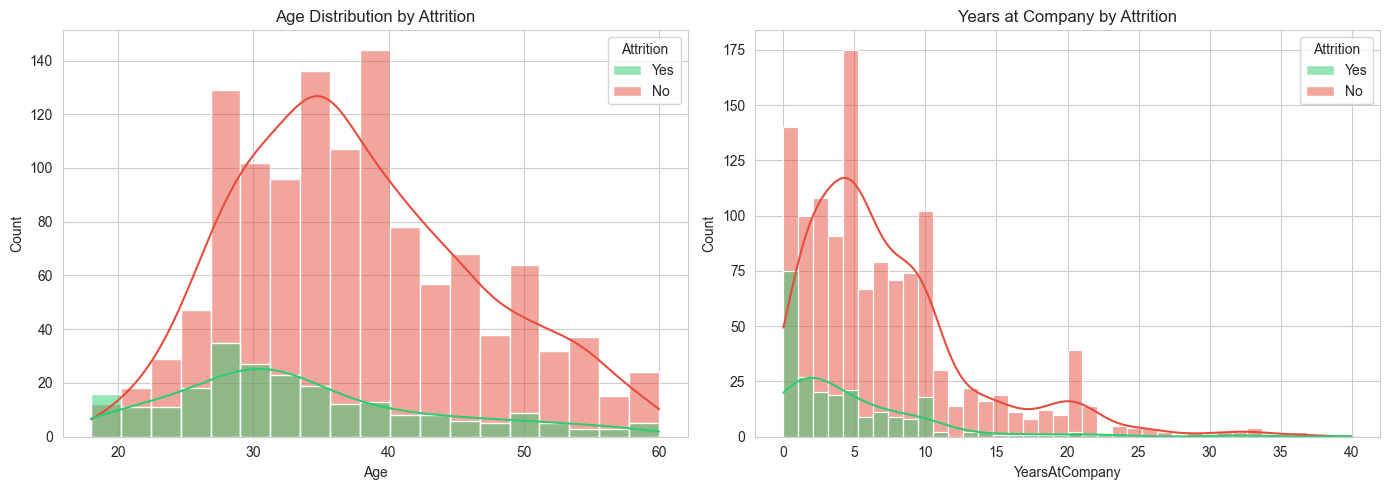

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="Age", hue="Attrition", kde=True, ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Age Distribution by Attrition")

sns.histplot(data=df, x="YearsAtCompany", hue="Attrition", kde=True, ax=axes[1], palette=["#2ecc71", "#e74c3c"])
axes[1].set_title("Years at Company by Attrition")

plt.tight_layout()
plt.show()

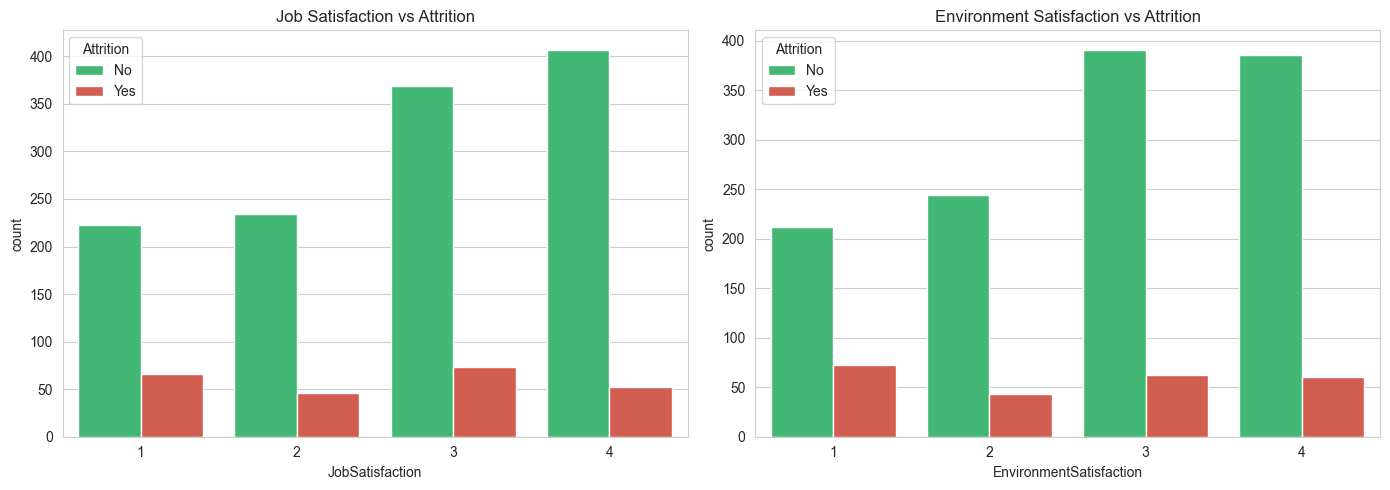

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="JobSatisfaction", hue="Attrition", ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Job Satisfaction vs Attrition")

sns.countplot(data=df, x="EnvironmentSatisfaction", hue="Attrition", ax=axes[1], palette=["#2ecc71", "#e74c3c"])
axes[1].set_title("Environment Satisfaction vs Attrition")

plt.tight_layout()
plt.show()

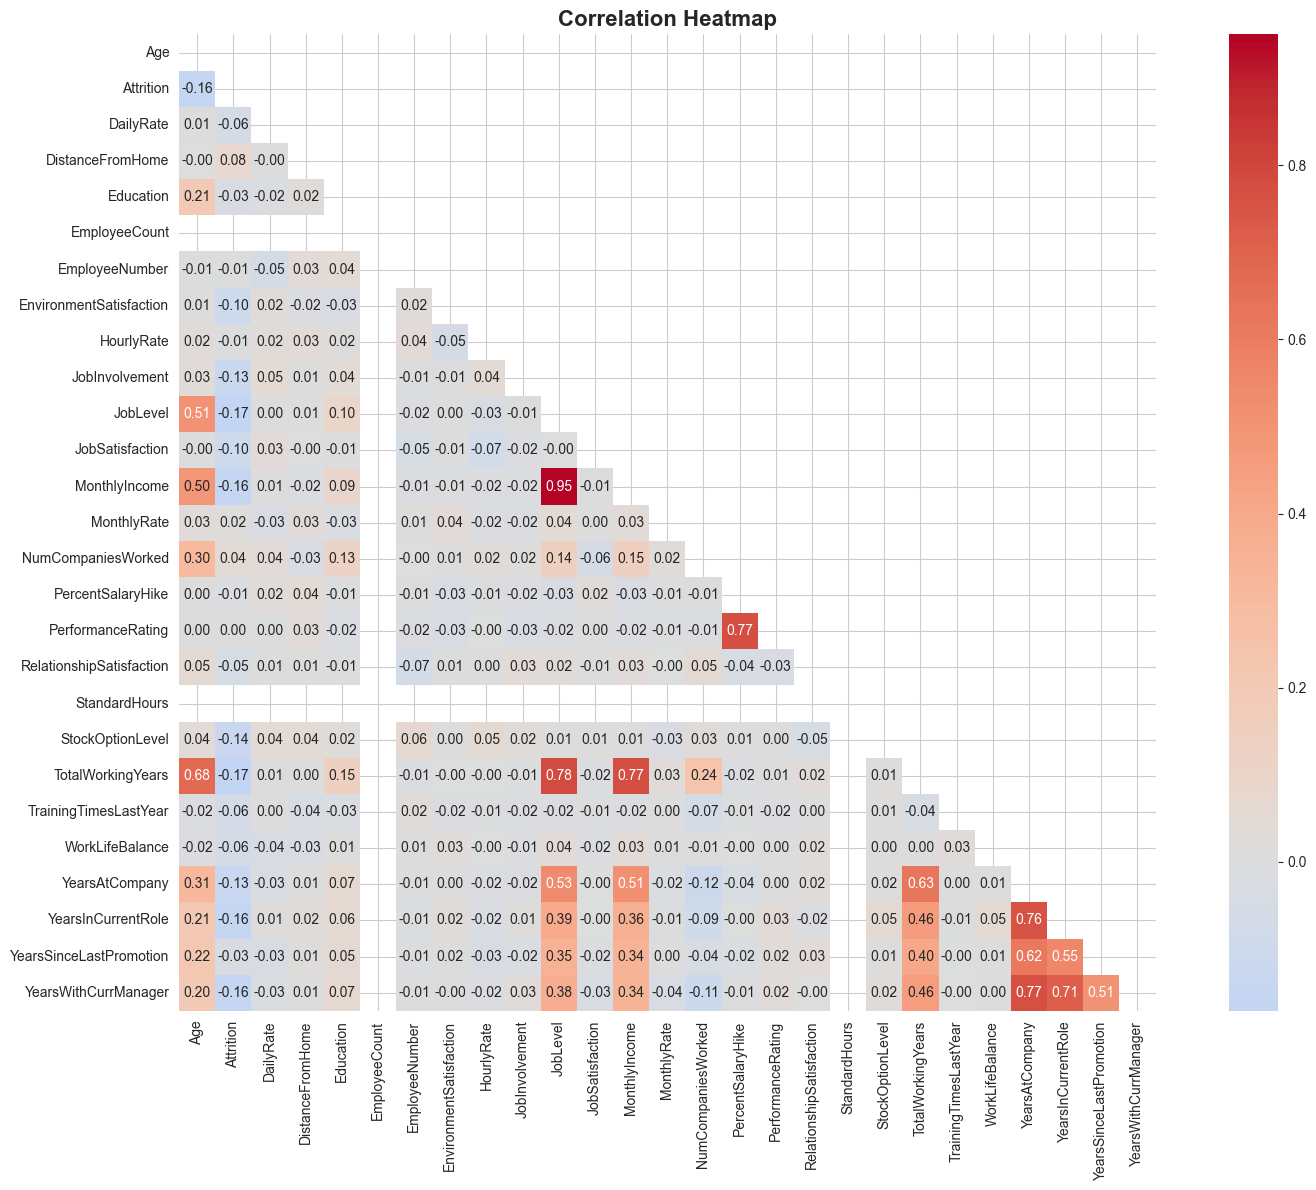

In [15]:
# Convert Attrition temporarily for correlation
df_corr = df.copy()
df_corr["Attrition"] = df_corr["Attrition"].map({"Yes": 1, "No": 0})

plt.figure(figsize=(16, 12))
corr = df_corr.select_dtypes(include=["int64", "float64"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # optional: upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
print("="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

print("""
1. Attrition Rate is around 16% → Dataset is imbalanced.

2. OverTime has a very strong relationship with attrition.
   Employees working overtime leave at a much higher rate.

3. Sales department shows higher attrition compared to others.

4. Lower Monthly Income is associated with higher attrition.

5. Younger employees and those with fewer years at the company 
   tend to leave more frequently.

6. Low Job Satisfaction and Environment Satisfaction increase 
   the chance of attrition.

7. The dataset has no missing values and no duplicate rows.
""")

KEY INSIGHTS FROM EDA

1. Attrition Rate is around 16% → Dataset is imbalanced.

2. OverTime has a very strong relationship with attrition.
   Employees working overtime leave at a much higher rate.

3. Sales department shows higher attrition compared to others.

4. Lower Monthly Income is associated with higher attrition.

5. Younger employees and those with fewer years at the company 
   tend to leave more frequently.

6. Low Job Satisfaction and Environment Satisfaction increase 
   the chance of attrition.

7. The dataset has no missing values and no duplicate rows.

